# BUCSS 2026
## AI Session Hands-On Part 2: Training different models for Task 1

In this notebook you will:
- Load the training data
- Train AI models
- Vary station and model
- Note: Effect of history length is covered in the last cell

In [ ]:
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import cmcrameri.cm as cmc
import random
import statsmodels.api as sm
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import root_mean_squared_error, r2_score

#These are internal
import sys
sys.path.insert(0, "../scripts")
# print(sys.path)
from splitting_and_training import split_data, train_model, feature_selection, prepare_station_training_data, explain_model, calc_importance
from plotting import obs_map, plot_scatter_and_residuals, plot_stats, plot_importance, plot_shap_summary

random.seed(42)  # define seed to create deterministic results by pseudo-randomness


First we need to decide if we want every column in our dataframe as a feature in our ML model. 

In [2]:
def load_and_prepre_data(city="dortmund", station="DOBBHS"):
    """Loads dataframe

    Args:
        city (str): One of ["ghent", "dortmund"]. Defaults to "dortmund".
        station (str). Station name, e.g. "DOBBHS" for dortmund or "BEL_GNE_001" for ghent
    """
    # 1) Load data
    df = pd.read_parquet(f"../dataframes_for_training/{city}_training.parquet")

    hod = df["datetime_utc"].dt.hour
    doy = df["datetime_utc"].dt.dayofyear
    df["tod_sin"] = np.sin(2 * np.pi * hod / 24)
    df["tod_cos"] = np.cos(2 * np.pi * hod / 24)
    df["doy_sin"] = np.sin(2 * np.pi * doy / 365)
    df["doy_cos"] = np.cos(2 * np.pi * doy / 365)

    # All Stations
    print(f'Stations: {list(df["station_id"].unique())}')
    df = df[df["station_id"] == station]

    print(df.columns)

    # 2) Prepare possible target variables
    # Add columns for different target variables to the dataframe
    # (the defined target) DeltaT
    df["temp_diff"] = df["air_temperature"] - df["t2m_corr"]
    # The simple predictors
    # (a) DeltaT = 0 --> use column "t2m_corr" directly
    # (b) constant mean offset
    df["mean_offset"] = df["t2m_corr"].mean()
    # (c) mean diurnal cycle
    df["hour"] = df["datetime_utc"].dt.hour
    mean_diurnal_offset_dict = df.groupby("hour")["temp_diff"].mean().to_dict()
    df["mean_diurnal_offset"] = df["hour"].apply(lambda h: mean_diurnal_offset_dict[h])
    df.drop(columns=["hour"], inplace=True)

    return df

city = "dortmund"
df = load_and_prepre_data(city)

Stations: ['DOBBHS', 'DOBBRS', 'DOBCLA', 'DOBDHS', 'DOBDKP', 'DOBDOU', 'DOBGAS', 'DOBHAN', 'DOBHAP', 'DOBHBF', 'DOBHKS', 'DOBKPW', 'DOBMSP', 'DOBNOM', 'DOBOHS', 'DOBPSW', 'DOBSBA', 'DOBSPS', 'DOBWEP', 'DOBWFH', 'DOBWFP', 'DODBOL', 'DODFRP', 'DODGWS', 'DODPHX', 'DOTABA', 'DOTABS', 'DOTADK', 'DOTADR', 'DOTADS', 'DOTAKU', 'DOTAMB', 'DOTAMS', 'DOTAMW', 'DOTAWG', 'DOTAWS', 'DOTBES', 'DOTBGS', 'DOTBHS', 'DOTBOS', 'DOTBSW', 'DOTEPM', 'DOTFBK', 'DOTFBP', 'DOTFHS', 'DOTFLU', 'DOTGRW', 'DOTHGW', 'DOTHSB', 'DOTIRS', 'DOTKLS', 'DOTKNS', 'DOTKOH', 'DOTKPS', 'DOTLST', 'DOTLTS', 'DOTOFH', 'DOTOHS', 'DOTPHX', 'DOTPKW', 'DOTPZW', 'DOTSBS', 'DOTSCS', 'DOTSFH', 'DOTSRW', 'DOTSTB', 'DOTSTS', 'DOTSWH', 'DOTSWS', 'DOTTPS', 'DOTVGS', 'DOTWBB', 'DOTWBS', 'DOTWFP', 'DOTWLW', 'DOTZHE']
Index(['station_id', 'latitude', 'longitude', 'datetime_utc',
       'air_temperature', 'bh_nearest', 'bh_buf50', 'bh_buf100', 'bh_buf250',
       'bh_buf500', 'bh_buf750', 'bh_buf1000', 'tcd_nearest', 'tcd_buf50',
       'tcd_bu

# The individual tasks

### 1. Select the target variable (explore different target variables here)

In [3]:
def create_dataset_with_target(df, target="temp_diff"):
    """Selects the target vaiable

    Args:
        df (pd.DataFrame): the data
        target (str): One column of the data, one of ["temp_diff" "t2m_corr" "mean_offset" "mean_diurnal_offset"]. Defaults to "temp_diff"
    
    Returns:
        X: dataframe without target colum (and related columns)
        y: target colum
    """
    target_col = df[target]

    # drop any possible target variable from the training dataframe (X)
    target_options = ["air_temperature", "temp_diff", "mean_offset", "mean_diurnal_offset"]
    if target == "t2m_corr":
        target_options.extend(["t2m_corr", "t2m"])
    X = df.drop(columns=target_options).copy()

    # Set y as the target column
    y = target_col

    return X, y

# CHANGE TARGET VARIABLE WITH THREE SIMPLE PREDICTORS:
target = "temp_diff"
X, y = create_dataset_with_target(df, target)

In [4]:
# for the two city tasks the given history lengths are predifined
history_lengths = {
    'dortmund': {
        '1week': 7 * 24,            # 168 hours
        '2weeks': 2 * 7 * 24,       # 336 hours
        '1month': 30 * 24,          # ~720 hours
        '3months': 3 * 30 * 24,     # ~2160 hours
        '6months': 6 * 30 * 24,     # ~4320 hours
        '11months': 11 * 30 * 24,   # ~7920 hours
    },
    'ghent' : {
        '1week': 7 * 24,        # 168 hours
        '1month': 30 * 24,      # ~720 hours
        '3months': 90 * 24,     # ~2160 hours
        '1year': 365 * 24,      # ~8760 hours
        '3years': 3 * 365 * 24, # ~26280 hours
        '6years': 6 * 365 * 24, # ~52560 hours
    }
}

### 2. Split the data into training and validation sets

In [5]:
# VARY PARAMETERS
# (a) history
# - for ghent history can be one of [1week, 1month, 3months, 1year, 3years, 6years]
# - for dortmund history can be one of [1week, 2weeks, 1month, 3months, 6months, 11months]
# (b) start_date_lag
# to select train subsets from different start dates give a __number of hours__ by which the selection window is shifted
X_train, X_val, y_train, y_val = prepare_station_training_data(X, y, city, history_length=history_lengths[city]["1week"], start_date_lag=0)

### 3. Model and Feature selection

In [6]:
MODEL_TYPE = "lur" # "xgboost", "randomforest", "lur"

# Check feature_selection function
print(X_train.shape, y_train.shape, X_val.shape, y_val.shape, target)
features = feature_selection(MODEL_TYPE, X_train, y_train, X_val, y_val, target)
print("Features", features)

# We subset our predictor tables by only keeping the selected features
X_train_sel = X_train[features]
X_val_sel   = X_val[features]

(168, 60) (168,) (840, 60) (840,) temp_diff
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9354
added ssrd_deac            recon_val_R²=0.9368
LUR: 3 predictors, recon_val_R²=0.9368
Features ['tod_sin', 'tod_cos', 'ssrd_deac']


### 4. Scaling



In [7]:
SCALE = True

def scale_data(target, X_train_sel,X_val_sel):
    """Scales data with MinMax or standardScaler if applicable

    Args:
        target (str): the target column
        X_train_sel (pd.DataFrame): The training set
        X_val_sel (_type_): The validation set

    Returns:
        _type_: _description_
    """
    # Save unscaled ERA5-Land input bc it's needed for error metrics
    if target == "t2m_corr":
        t2m_corr = y_val
    else:
        t2m_corr = X_val["t2m_corr"]

    # scale all predicors except for the temporal predictors (already -1 to 1)
    cyclical = {"tod_sin", "tod_cos", "doy_sin", "doy_cos"}
    minmax_cols = [c for c in ["ssrd_deac", "tp_deac"] if c in X_train_sel.columns]

    # select the predictors to be scaled
    std_cols = [c for c in X_train_sel.columns
                if c not in cyclical and c not in minmax_cols]

    
    X_train_sel = X_train_sel.copy()
    X_val_sel = X_val_sel.copy()

    # use sklearn's StandardScaler: scales by sample mean and variance
    std_scaler  = StandardScaler()
    mm_scaler = MinMaxScaler()

    # fit the mean and variance from the training data, scale the training data
    if len(std_cols) > 0:
        X_train_sel[std_cols] = std_scaler.fit_transform(X_train_sel[std_cols])
    if len(minmax_cols) > 0:
        X_train_sel[minmax_cols] = mm_scaler.fit_transform(X_train_sel[minmax_cols])
    else:
        print("Info: No minmax_cols available")

    # apply the training fit to scale the validation data
    if len(std_cols) > 0:
        X_val_sel[std_cols]   = std_scaler.transform(X_val_sel[std_cols])
    if len(minmax_cols) > 0:
        X_val_sel[minmax_cols] = mm_scaler.transform(X_val_sel[minmax_cols])
    
    return t2m_corr, X_train_sel, X_val_sel, minmax_cols, std_cols, mm_scaler, std_scaler

if SCALE:
    t2m_corr, X_train_sel, X_val_sel, minmax_cols, std_cols, mm_scaler, std_scaler = scale_data(target, X_train_sel, X_val_sel)

In [8]:
# print(df[["air_temperature", "t2m", "t2m_corr", "dtm_nearest"]].describe())
# print("mean obs - t2m_corr:", (df["air_temperature"] - df["t2m_corr"]).mean())

### 5. Model training / fitting

In [9]:
# see train_model function

y_pred, model = train_model(X_train_sel, X_val_sel, y_train, y_val, model_type = MODEL_TYPE)

const        1.294336
ssrd_deac   -0.228738
tod_cos      0.172003
tod_sin     -0.007527
dtype: float64


In [10]:
def calc_effect_of_cyclic_aspects(model, print_it=False):
    """Calculate effect of a certain hour (TOD) or day (DOY) to the model result

    Args:
        print_it (bool, optional): whether to print the results. Defaults to False.

    Returns:
        dict: hourly and daily resolved effects
    """
    impact_tod = {}
    impact_doy = {}

    if model.params.get("tod_sin"):
        hours = np.arange(24)
        cos_comp = model.params["tod_cos"] * np.cos(2 * np.pi * hours / 24) 
        sin_comp = model.params["tod_sin"] * np.sin(2 * np.pi * hours / 24)
        tod = cos_comp + sin_comp
        impact_tod = dict(zip(hours, tod))
        if print_it:
            for h, v in zip(hours, tod):
                print(f"hour {h:02d}: TOD contribution {v:+.3f} °C")

    if model.params.get("doy_sin"):
        days = np.arange(15, 366, 30)
        cos_comp = model.params["doy_cos"] * np.cos(2 * np.pi * days / 365) 
        sin_comp = model.params["doy_sin"] * np.sin(2 * np.pi * days / 365)
        doy = cos_comp + sin_comp        
        impact_doy = dict(zip(days, doy))
        if print_it:
            for d, v in zip(days, doy):
                print(f"month {int(d/30)+1}: DOY contribution {v:+.3f} °C")
    results = {
        "impact_tod": impact_tod,
        "impact_doy":impact_doy,
    }
    return results

if MODEL_TYPE == "lur":
    calc_effect_of_cyclic_aspects(model, print_it=True)

hour 00: TOD contribution +0.172 °C
hour 01: TOD contribution +0.164 °C
hour 02: TOD contribution +0.145 °C
hour 03: TOD contribution +0.116 °C
hour 04: TOD contribution +0.079 °C
hour 05: TOD contribution +0.037 °C
hour 06: TOD contribution -0.008 °C
hour 07: TOD contribution -0.052 °C
hour 08: TOD contribution -0.093 °C
hour 09: TOD contribution -0.127 °C
hour 10: TOD contribution -0.153 °C
hour 11: TOD contribution -0.168 °C
hour 12: TOD contribution -0.172 °C
hour 13: TOD contribution -0.164 °C
hour 14: TOD contribution -0.145 °C
hour 15: TOD contribution -0.116 °C
hour 16: TOD contribution -0.079 °C
hour 17: TOD contribution -0.037 °C
hour 18: TOD contribution +0.008 °C
hour 19: TOD contribution +0.052 °C
hour 20: TOD contribution +0.093 °C
hour 21: TOD contribution +0.127 °C
hour 22: TOD contribution +0.153 °C
hour 23: TOD contribution +0.168 °C


### 6. Error metrics (Compute the test RMSE here)

In [11]:
# we ensure the metrics are valid for both targets
add_back = t2m_corr.values if target == "temp_diff" else 0

y_obs = y_val.values + add_back
y_model = y_pred + add_back

rmse = root_mean_squared_error(y_obs, y_model)
r2 = r2_score(y_obs, y_model)
bias = np.mean(y_model - y_obs)


print(f"{MODEL_TYPE} and target {target} Validation RMSE: {rmse:.2f} °C   R²: {r2:.2f}   Bias: {bias:.2f} °C")

# # baseline: ERA5-corrected alone vs observed
# rmse_era5 = np.sqrt(mean_squared_error(y_rec, t2m_corr.values))
# r2_era5   = r2_score(y_rec, t2m_corr.values)
# print(f"ERA5 RMSE: {rmse_era5:.3f} °C   R²: {r2_era5:.3f}")


lur and target temp_diff Validation RMSE: 1.12 °C   R²: 0.94   Bias: 0.20 °C


### 7. Explain Weights / SHAP values

1) create explainer and compute SHAP values for the test set

In [12]:
if MODEL_TYPE == "xgboost":
    explainer = shap.TreeExplainer(model)
    print("  Calculating SHAP values...")
    shap_values = explainer.shap_values(X_val_sel)

    print(f"  SHAP values: {shap_values.shape[0]} predictions × {shap_values.shape[1]} features")
    print(f"  Base value: {explainer.expected_value:.4f}")

2) plot "compact representation of the distribution and variability of SHAP values"

In [13]:
if MODEL_TYPE == "xgboost":
    plot_shap_summary(shap_values, X_val_sel)

3) plot "explanations for individual predictions"

In [14]:
if MODEL_TYPE == "xgboost":
    
    # for 98th percentile value
    diff = y_model - t2m_corr.values
    perc = np.percentile(diff, 98)                      # the 98th-percentile VALUE
    sample_idx = np.abs(diff - perc).argmin() 

    # # for maximum
    # sample_idx = diff.argmax()


    val_row_label = X_val_sel.index[sample_idx]      
    station  = df.loc[val_row_label, "station_id"]
    datetime = df.loc[val_row_label, "datetime_utc"] 
    print(f"Station coordinates are {df.loc[val_row_label, "latitude"]}, {df.loc[val_row_label, "longitude"]}")
    
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[sample_idx],
            base_values=explainer.expected_value,
            data=X_val_sel.iloc[sample_idx],
            feature_names=X_val_sel.columns.tolist()
        ),
        max_display=10,
        show=False
    )
    plt.title(f'Single sample explanation at {station} at {datetime}')
    plt.tight_layout()
    plt.show()

4) plot unscaled "explanations for individual predictions"

In [15]:
if MODEL_TYPE == "xgboost":
    # the scaled val row you're explaining
    scaled_row = X_val_sel.iloc[[sample_idx]]      # keep as 1-row DataFrame

    # inverse-transform only the scaled columns
    unscaled = scaled_row.copy()
    unscaled[std_cols] = std_scaler.inverse_transform(scaled_row[std_cols])
    unscaled[minmax_cols] = mm_scaler.inverse_transform(scaled_row[minmax_cols])

    # now unscaled has real feature values (cyclical cols were never scaled, so unchanged)
    data_display = unscaled.iloc[0]                # Series of real values for this row

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[sample_idx],
            base_values=explainer.expected_value,
            data=data_display.values,                    # unscaled values for display
            feature_names=X_val_sel.columns.tolist()
        ),
        max_display=10, show=False
    )
    plt.title(f'Single sample explanation at {station} at {datetime}')
    plt.tight_layout()
    plt.show()

5) plot feature importance

In [16]:
if MODEL_TYPE == "xgboost":
    calc_importance(model)

All five steps in one function
1) create explainer and compute SHAP values for the test set
2) plot "compact representation of the distribution and variability of SHAP values"
3) plot "explanations for individual predictions"
4) plot unscaled "explanations for individual predictions"
5) plot importance

In [17]:
def explain_xgboost(model, X_val_sel, y_model, t2m_corr, minmax_cols, std_cols):
    # 1) create explainer and compute SHAP values for the test set
    explainer = shap.TreeExplainer(model)
    print("  Calculating SHAP values...")
    shap_values = explainer.shap_values(X_val_sel)

    print(f"  SHAP values: {shap_values.shape[0]} predictions × {shap_values.shape[1]} features")
    print(f"  Base value: {explainer.expected_value:.4f}")

    # 2) plot "compact representation of the distribution and variability of SHAP values"
    plot_shap_summary(shap_values, X_val_sel)

    # 3) plot "explanations for individual predictions"
    # for 98th percentile value
    diff = y_model - t2m_corr.values
    perc = np.percentile(diff, 98)                      # the 98th-percentile VALUE
    sample_idx = np.abs(diff - perc).argmin() 

    # # for maximum
    # sample_idx = diff.argmax()
    val_row_label = X_val_sel.index[sample_idx]      
    station  = df.loc[val_row_label, "station_id"]
    datetime = df.loc[val_row_label, "datetime_utc"] 
    print(f"Station coordinates are {df.loc[val_row_label, 'latitude']}, {df.loc[val_row_label, 'longitude']}")
    
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[sample_idx],
            base_values=explainer.expected_value,
            data=X_val_sel.iloc[sample_idx],
            feature_names=X_val_sel.columns.tolist()
        ),
        max_display=10,
        show=False
    )
    plt.title(f'Single sample explanation at {station} at {datetime}')
    plt.tight_layout()
    plt.show()

    # 4) plot unscaled "explanations for individual predictions"
    # the scaled val row you're explaining
    scaled_row = X_val_sel.iloc[[sample_idx]]      # keep as 1-row DataFrame

    # inverse-transform only the scaled columns
    unscaled = scaled_row.copy()
    
    if len(std_cols) > 0:
        unscaled[std_cols] = std_scaler.inverse_transform(scaled_row[std_cols])
    if len(minmax_cols) > 0:
        unscaled[minmax_cols] = mm_scaler.inverse_transform(scaled_row[minmax_cols])

    # now unscaled has real feature values (cyclical cols were never scaled, so unchanged)
    data_display = unscaled.iloc[0]                # Series of real values for this row

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[sample_idx],
            base_values=explainer.expected_value,
            data=data_display.values,                    # unscaled values for display
            feature_names=X_val_sel.columns.tolist()
        ),
        max_display=10,
        show=False
    )
    plt.title(f'Single sample explanation at {station} at {datetime}')
    plt.tight_layout()
    plt.show()

    # 5) plot feature importance
    sorted_features, sorted_importances = calc_importance(model)

    plot_importance(sorted_features, sorted_importances)

if MODEL_TYPE=="xgboost":
    explain_xgboost(model, X_val_sel, y_model, t2m_corr, minmax_cols, std_cols)

# Summarize steps 2-7 into one workflow (keep target variable)

# Run the training three times per history length
Note that the model itself is not iteratively improved but rather trained from scratch each time. The results are then averaged over the three runs.

This also plots the required plots:
- Scatter plot of observed and predicted values in the validation set (once for each history length)
- Lineplot that shows the stats (RMSE, R2, Bias) per history length

In [18]:
def train_and_explain_model(df, model_name="lur", target="temp_diff", city="dortmund", station="DOBBHS"):
    """trains and explains a model based on the input parameters

    Args:
        df (pd.DataFrame): The data to train on
        model_name (str, optional): One of ["lur", "xgboost", "randomforest"]. Defaults to "lur".
        target (str, optional): One of ["temp_diff" "t2m_corr" "mean_offset" "mean_diurnal_offset"]. Defaults to "temp_diff".
        city (str, optional): _description_. Defaults to "dortmund".
    """

    df = load_and_prepre_data(city, station)

    # -------------------------------
    scale=True  # we want to scale the input parameters for better weighed features

    if history_lengths.get(city) is None:
        print(f"City {city} not prepared. Stopping")
        return

    # STEP 1: Select the target variable and create dataset
    X, y = create_dataset_with_target(df, target)

    # -------------------------------


    # Store results for all runs
    results = {
        length: {'rmse': [], 'r2': [], 'bias': [], 'cyclic_effects': []}
        for length in history_lengths.get(city)
    }

    # Get the total amount of hours that can be used as history length
    total_hours = np.array(list(history_lengths.get(city).values())).max()

    # Intuition: Loop through all history lengths
    for length_name, history_length in history_lengths.get(city).items():
        print(f"\nProcessing {length_name} ({history_length} hours)...")

        # Repeat training a model n times per history length
        repetitions = 3
        for rep in range(repetitions): 
            print(f"  Repetition {rep+1}/{repetitions}")

            # Generate random start date lag (in hours) within train data range
            # Ensure the window fits within the defined train data range
            max_start_lag = total_hours - history_length
            random_start_lag = random.randint(0, max_start_lag)
            start_time = df["datetime_utc"].min() + datetime.timedelta(hours=random_start_lag)
            # TODO: can we enforce certain seasons for the start_lag?
            print(f"-- START TIME: {start_time}")

            # STEP 2: Split data with selected history length and random start date (in hours)
            X_train, X_val, y_train, y_val = prepare_station_training_data(
                X, y, city,
                history_length=history_length,
                start_date_lag=random_start_lag
            )

            # STEP 3: Model and Feature selection (based on impact to R2)
            features = feature_selection(model_name, X_train, y_train, X_val, y_val, target)

            # Subset features
            X_train_sel = X_train[features]
            X_val_sel = X_val[features]

            # STEP 4: Scaling (if enabled)
            if scale:

                t2m_corr, X_train_sel, X_val_sel, minmax_cols, std_cols, mm_scaler, std_scaler = scale_data(target, X_train_sel, X_val_sel)


            # STEP 5: Model training / fitting
            y_pred, model = train_model(
                X_train_sel, X_val_sel,
                y_train, y_val,
                model_type=model_name
            )

            # STEP 6: Error metrics
            add_back = t2m_corr.values if target == "temp_diff" else 0
            y_obs = y_val.values + add_back
            y_model = y_pred + add_back

            rmse = root_mean_squared_error(y_obs, y_model)
            r2 = r2_score(y_obs, y_model)
            bias = np.mean(y_model - y_obs)

            # Store results
            results[length_name]['rmse'].append(rmse)
            results[length_name]['r2'].append(r2)
            results[length_name]['bias'].append(bias)
            results[length_name]['cyclic_effects'].append(calc_effect_of_cyclic_aspects(model))

            # STEP 7 (simplified): Explain weights / SHAP values
            if model_name == "xgboost":
                explain_xgboost(model_name, X_val_sel, y_model, t2m_corr, minmax_cols, std_cols)
            else:
                shap_values, X_val_subset =  explain_model(model, X_train_sel, X_val_sel)
                shap.summary_plot(shap_values, X_val_subset)
                plt.suptitle(f"{station}, {model_name}, {target}")



        # Plot the scatter and residuals of the last repetition
        plot_scatter_and_residuals(X_val, y_obs, y_model, length_name, start_time, station, model_name, target)

    # Plot efffect of history length on RMSE, R2 and Bias
    plot_stats(results, station, model_name, target)

    # Print summary table
    print("\nSummary of Results:")
    print(f"\nTrained with Features {features}")
    print("{:<12} {:<10} {:<10} {:<10} {:<10} {:<10}".format(
        "History", "RMSE Mean", "RMSE Std", "R2 Mean", "R2 Std", "Bias Mean"))

    lengths = list(results.keys())
    for length in lengths:
        print("{:<12} {:<10.2f} {:<10.2f} {:<10.2f} {:<10.2f} {:<10.2f}".format(
            length,
            np.mean(results[length]['rmse']),
            np.std(results[length]['rmse']),
            np.mean(results[length]['r2']),
            np.std(results[length]['r2']),
            np.mean(results[length]['bias'])
        ))
    return results
    # Note: results is returned to plot the contibution of cyclic parameters, see cells below

Stations: ['DOBBHS', 'DOBBRS', 'DOBCLA', 'DOBDHS', 'DOBDKP', 'DOBDOU', 'DOBGAS', 'DOBHAN', 'DOBHAP', 'DOBHBF', 'DOBHKS', 'DOBKPW', 'DOBMSP', 'DOBNOM', 'DOBOHS', 'DOBPSW', 'DOBSBA', 'DOBSPS', 'DOBWEP', 'DOBWFH', 'DOBWFP', 'DODBOL', 'DODFRP', 'DODGWS', 'DODPHX', 'DOTABA', 'DOTABS', 'DOTADK', 'DOTADR', 'DOTADS', 'DOTAKU', 'DOTAMB', 'DOTAMS', 'DOTAMW', 'DOTAWG', 'DOTAWS', 'DOTBES', 'DOTBGS', 'DOTBHS', 'DOTBOS', 'DOTBSW', 'DOTEPM', 'DOTFBK', 'DOTFBP', 'DOTFHS', 'DOTFLU', 'DOTGRW', 'DOTHGW', 'DOTHSB', 'DOTIRS', 'DOTKLS', 'DOTKNS', 'DOTKOH', 'DOTKPS', 'DOTLST', 'DOTLTS', 'DOTOFH', 'DOTOHS', 'DOTPHX', 'DOTPKW', 'DOTPZW', 'DOTSBS', 'DOTSCS', 'DOTSFH', 'DOTSRW', 'DOTSTB', 'DOTSTS', 'DOTSWH', 'DOTSWS', 'DOTTPS', 'DOTVGS', 'DOTWBB', 'DOTWBS', 'DOTWFP', 'DOTWLW', 'DOTZHE']
Index(['station_id', 'latitude', 'longitude', 'datetime_utc',
       'air_temperature', 'bh_nearest', 'bh_buf50', 'bh_buf100', 'bh_buf250',
       'bh_buf500', 'bh_buf750', 'bh_buf1000', 'tcd_nearest', 'tcd_buf50',
       'tcd_bu

100%|██████████| 100/100 [00:00<00:00, 529.47it/s]


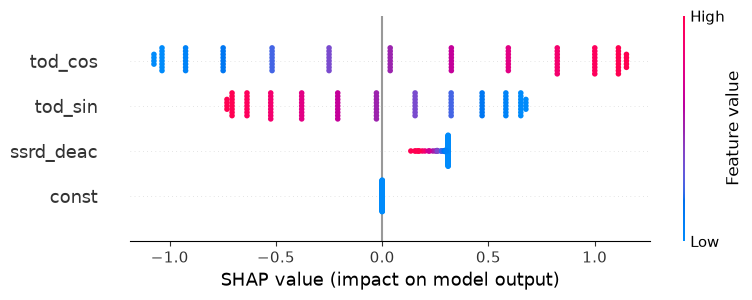

  Repetition 2/3
-- START TIME: 2025-02-08 01:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9060
added ['bh_buf50']                   recon_val_R²=0.9060
added ['imp_buf750']                 recon_val_R²=0.9060
added ssrd_deac            recon_val_R²=0.9292
added sp                   recon_val_R²=0.9300
added ssrd                 recon_val_R²=0.9317
added dtm_nearest          recon_val_R²=0.9317
LUR: 8 predictors, recon_val_R²=0.9317
ssrd_deac     -3.368881e+00
const          1.482473e+00
tod_sin        5.865789e-01
ssrd           3.827058e-01
tod_cos        3.494893e-01
sp            -5.162498e-02
bh_buf50       6.386949e-16
imp_buf750     6.552985e-18
dtm_nearest    0.000000e+00
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 360.80it/s]


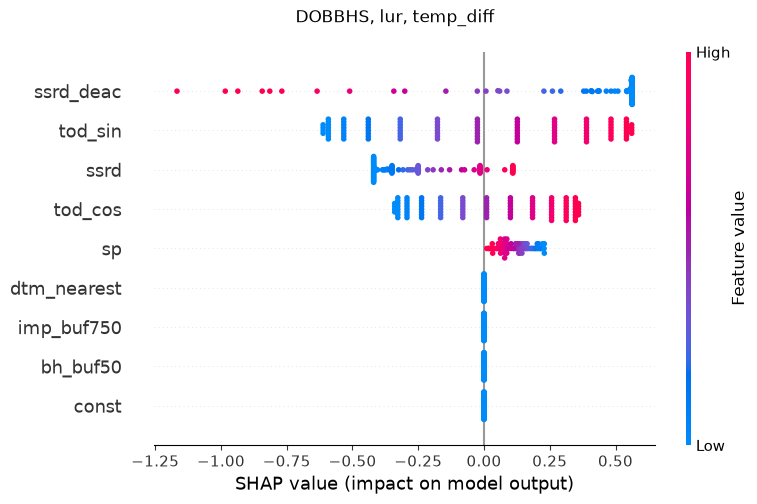

  Repetition 3/3
-- START TIME: 2025-01-09 13:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.8136
added ['wspd']                       recon_val_R²=0.8544
added ['bh_buf1000']                 recon_val_R²=0.8544
added ['imp_nearest']                recon_val_R²=0.8544
LUR: 5 predictors, recon_val_R²=0.8544
Info: No minmax_cols available
const          2.585409
tod_cos        0.540659
wspd          -0.439941
tod_sin        0.263694
bh_buf1000     0.000000
imp_nearest    0.000000
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 556.10it/s]


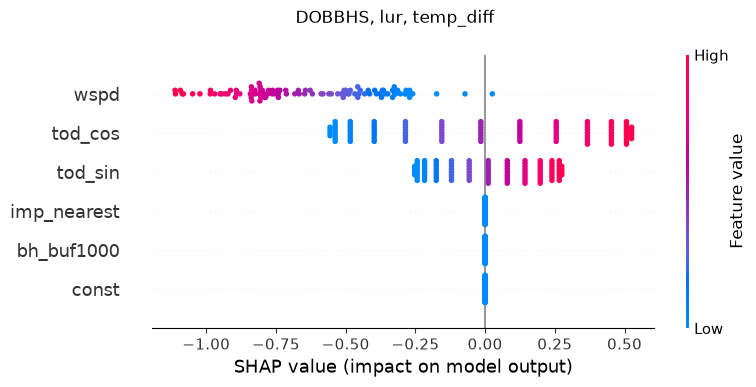

<Figure size 640x480 with 0 Axes>

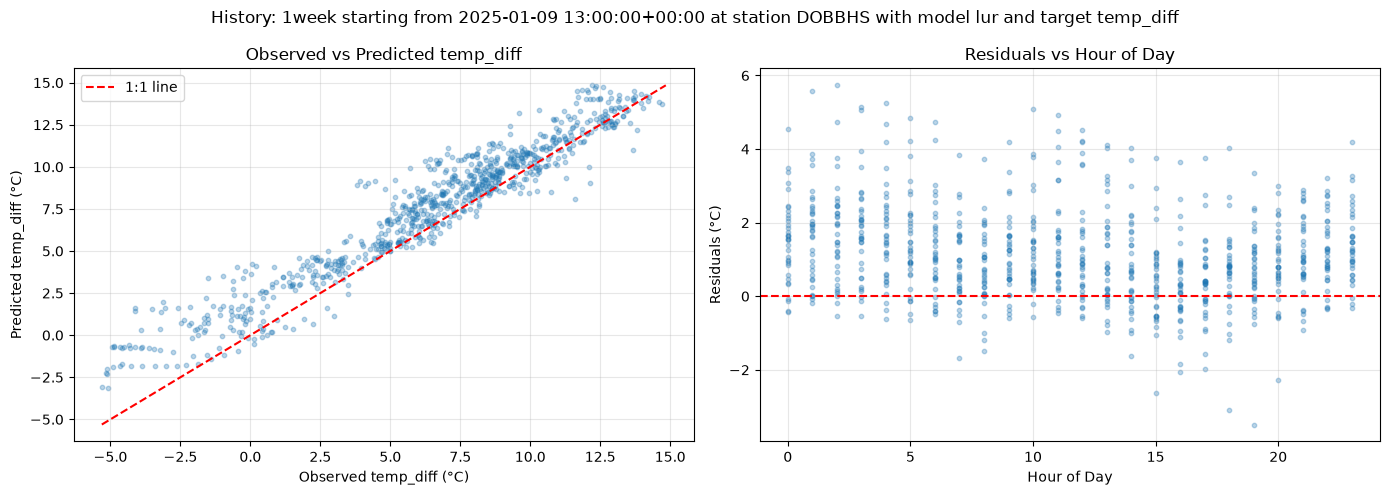


Processing 2weeks (336 hours)...
  Repetition 1/3
-- START TIME: 2025-09-11 03:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9311
added ['u10', 'v10']                 recon_val_R²=0.9364
added ssrd_deac            recon_val_R²=0.9405
LUR: 5 predictors, recon_val_R²=0.9405
ssrd_deac   -1.123183
const        1.011554
tod_sin     -0.349819
v10          0.328626
u10         -0.085362
tod_cos      0.069126
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 399.19it/s]


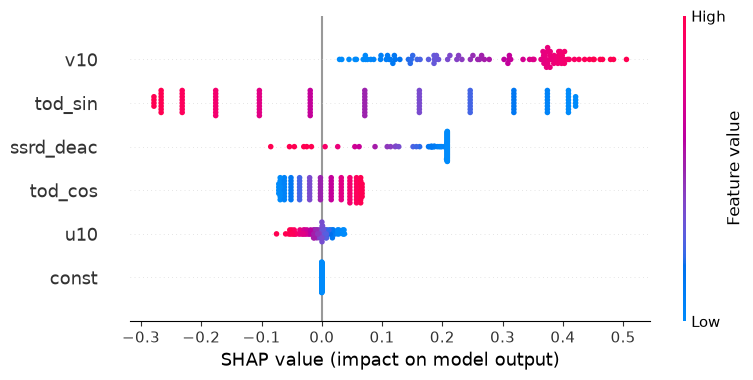

  Repetition 2/3
-- START TIME: 2025-04-04 22:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.8941
added ['rh']                         recon_val_R²=0.8967
added ['wspd']                       recon_val_R²=0.9015
added ['tcd_buf750']                 recon_val_R²=0.9015
added ['imp_buf250']                 recon_val_R²=0.9015
added ssrd_deac            recon_val_R²=0.9217
added ssrd                 recon_val_R²=0.9309
LUR: 8 predictors, recon_val_R²=0.9309
ssrd_deac    -2.413553e+00
const         2.141094e+00
tod_cos       5.116101e-01
ssrd          3.579413e-01
rh           -3.343309e-01
wspd         -2.113819e-01
tod_sin       8.055660e-02
tcd_buf750   -1.181562e-16
imp_buf250    0.000000e+00
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 267.28it/s]


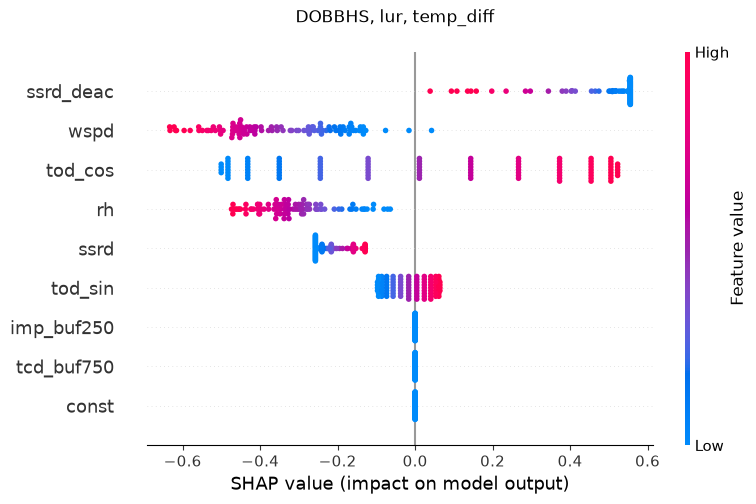

  Repetition 3/3
-- START TIME: 2025-03-25 15:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.8761
added ['wspd']                       recon_val_R²=0.8849
added ['bh_buf250']                  recon_val_R²=0.8849
added ['imp_buf100']                 recon_val_R²=0.8849
added ssrd                 recon_val_R²=0.9043
added ssrd_deac            recon_val_R²=0.9166
added dtm_nearest          recon_val_R²=0.9166
LUR: 8 predictors, recon_val_R²=0.9166
const          2.150847e+00
ssrd_deac     -1.344287e+00
tod_cos        6.089507e-01
ssrd           4.302734e-01
wspd          -3.306373e-01
tod_sin       -1.607458e-01
bh_buf250      1.335853e-16
imp_buf100     0.000000e+00
dtm_nearest    0.000000e+00
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 352.65it/s]


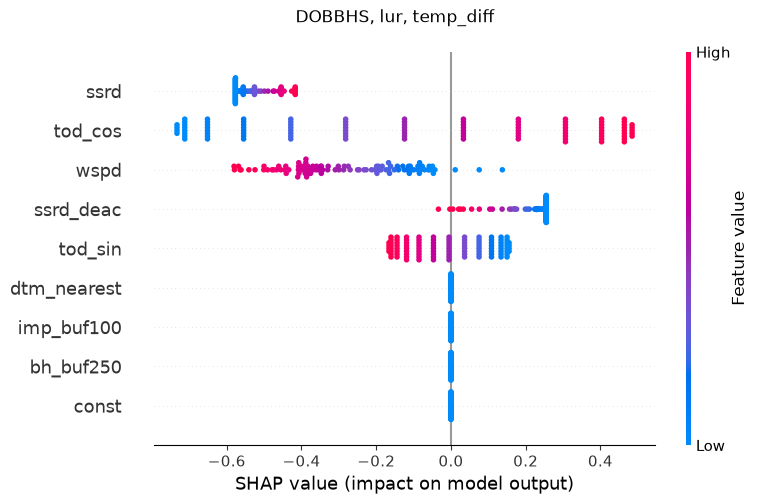

<Figure size 640x480 with 0 Axes>

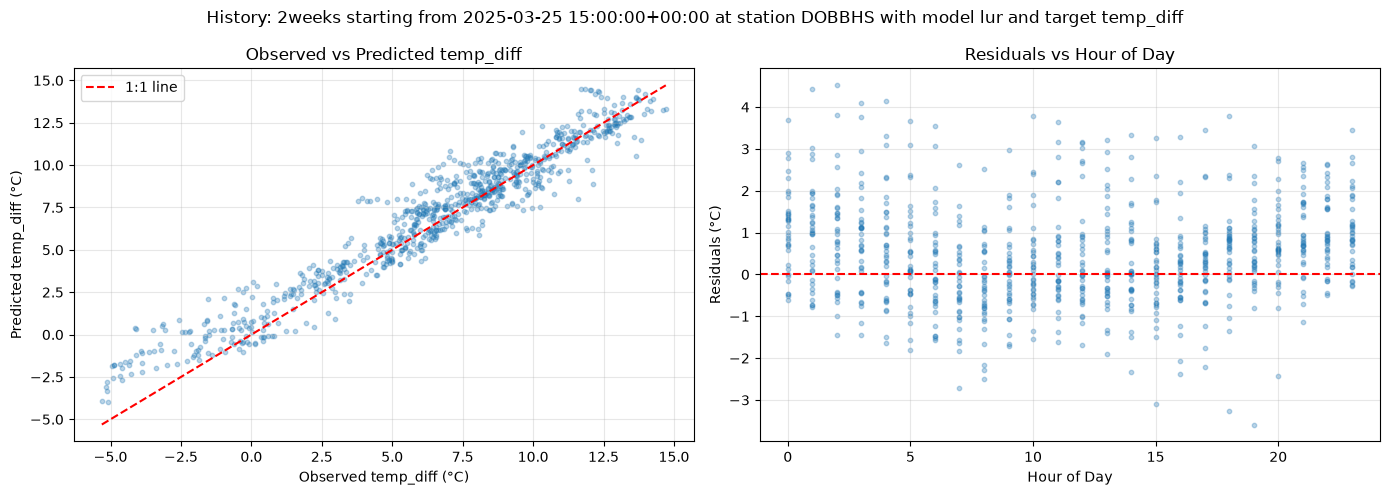


Processing 1month (720 hours)...
  Repetition 1/3
-- START TIME: 2025-03-18 05:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.8689
added ['rh']                         recon_val_R²=0.8751
added ['wspd']                       recon_val_R²=0.8852
added ['bh_buf250']                  recon_val_R²=0.8852
added ['imp_buf100']                 recon_val_R²=0.8852
added ssrd_deac            recon_val_R²=0.9026
added ssrd                 recon_val_R²=0.9206
added dtm_nearest          recon_val_R²=0.9206
LUR: 9 predictors, recon_val_R²=0.9206
const          2.311709e+00
ssrd_deac     -2.045727e+00
tod_cos        7.680696e-01
ssrd           3.796587e-01
rh            -3.277824e-01
wspd          -2.384289e-01
tod_sin        6.707367e-03
bh_buf250      3.136104e-16
imp_buf100     0.000000e+00
dtm_nearest    0.000000e+00
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 307.20it/s]


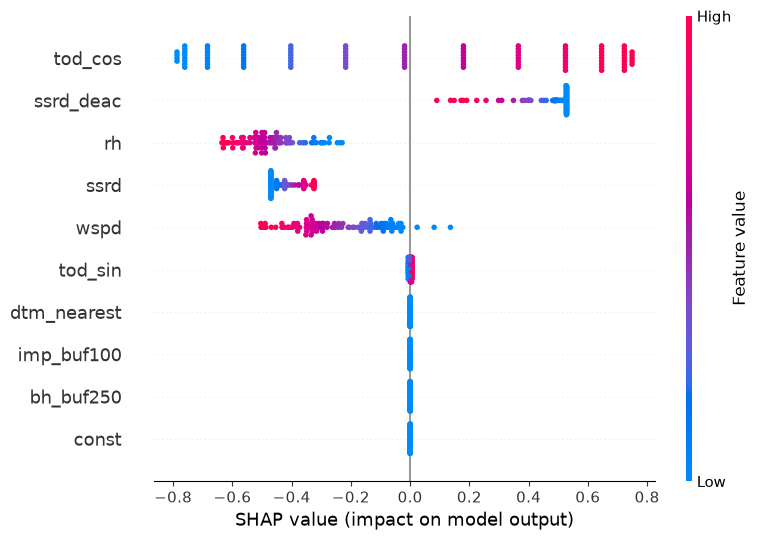

  Repetition 2/3
-- START TIME: 2025-02-17 16:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.8648
added ['wspd']                       recon_val_R²=0.8681
added ['bh_buf50']                   recon_val_R²=0.8681
added ['imp_buf750']                 recon_val_R²=0.8681
added ssrd                 recon_val_R²=0.9016
added ssrd_deac            recon_val_R²=0.9240
added sp                   recon_val_R²=0.9246
LUR: 8 predictors, recon_val_R²=0.9246
ssrd_deac    -2.783632e+00
const         2.427672e+00
ssrd          1.110451e+00
tod_sin       7.471853e-01
tod_cos       4.784943e-01
sp           -4.574033e-02
wspd          3.039310e-02
bh_buf50      1.542098e-16
imp_buf750   -1.336264e-16
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 315.25it/s]


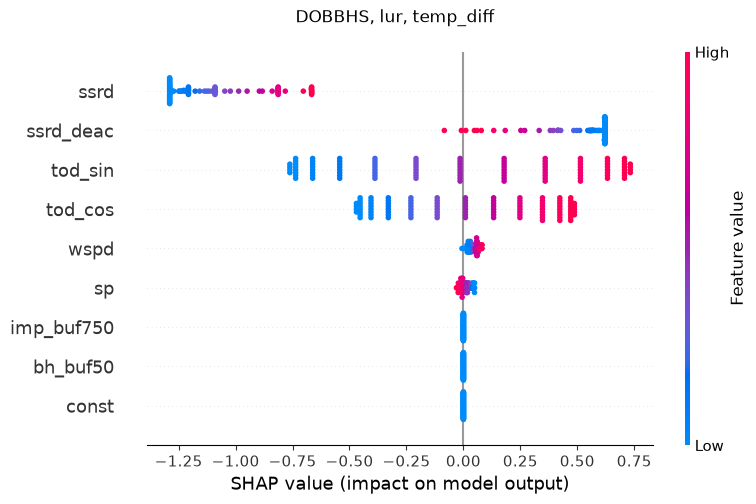

  Repetition 3/3
-- START TIME: 2025-09-09 10:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9254
added ['d2m']                        recon_val_R²=0.9255
added ['u10', 'v10']                 recon_val_R²=0.9331
added ['bh_buf750']                  recon_val_R²=0.9331
added ssrd_deac            recon_val_R²=0.9376
added tp_deac              recon_val_R²=0.9399
added tp                   recon_val_R²=0.9404
added dtm_nearest          recon_val_R²=0.9404
LUR: 10 predictors, recon_val_R²=0.9404
tp_deac       -1.359780e+00
const          7.879891e-01
ssrd_deac     -7.169014e-01
tod_cos        3.011490e-01
tod_sin       -2.565306e-01
v10            2.468493e-01
u10           -1.017260e-01
tp            -9.183574e-02
d2m           -2.958056e-02
bh_buf750      1.796376e-17
dtm_nearest    0.000000e+00
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 130.29it/s]


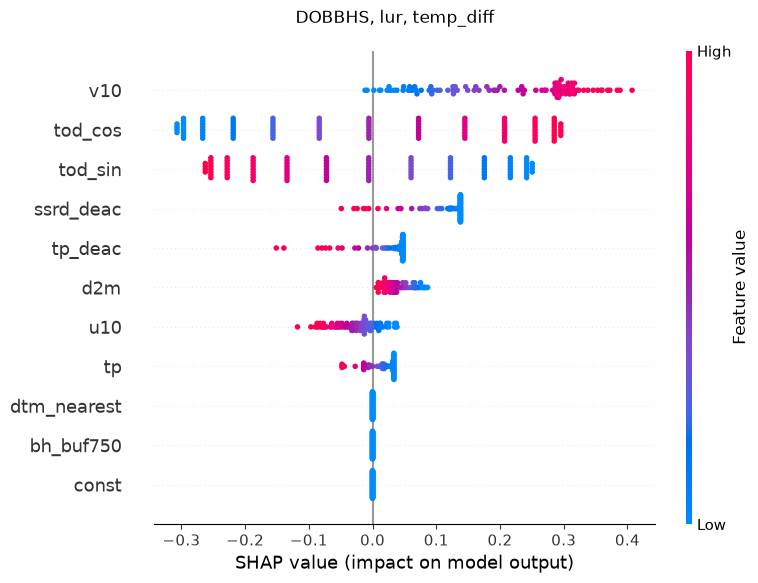

<Figure size 640x480 with 0 Axes>

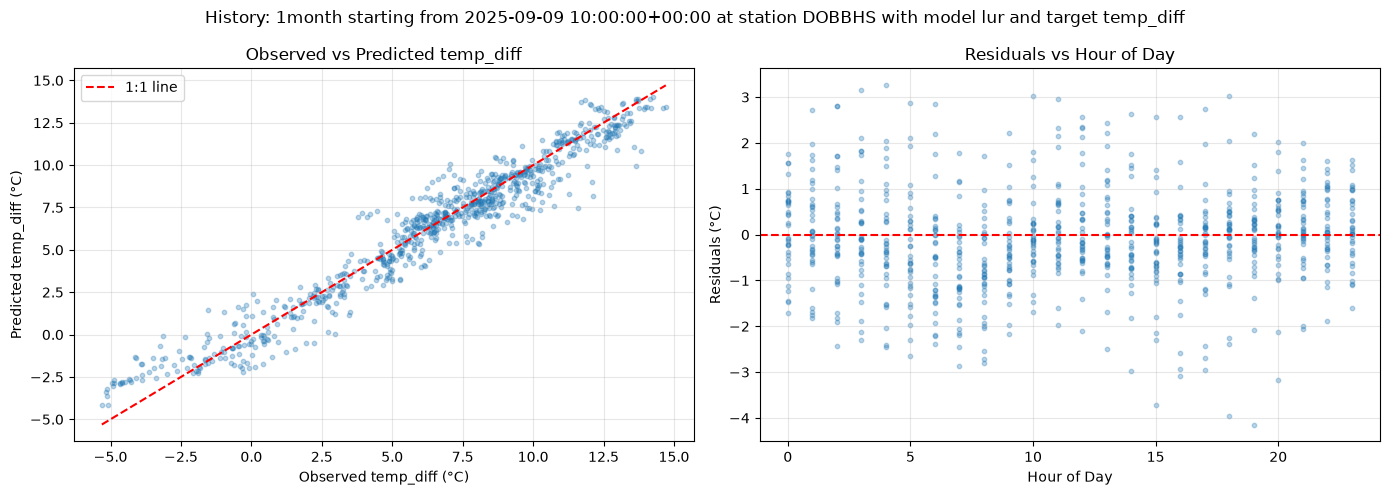


Processing 3months (2160 hours)...
  Repetition 1/3
-- START TIME: 2025-02-05 00:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.8899
added ['t2m_corr']                   recon_val_R²=0.8915
added ['rh']                         recon_val_R²=0.8919
added ['wspd']                       recon_val_R²=0.8962
added ['bh_buf50']                   recon_val_R²=0.8962
added ['tcd_buf100']                 recon_val_R²=0.8962
added ssrd_deac            recon_val_R²=0.9144
added ssrd                 recon_val_R²=0.9282
added tp_deac              recon_val_R²=0.9285
added dtm_nearest          recon_val_R²=0.9285
LUR: 11 predictors, recon_val_R²=0.9285
tp_deac       -3.607019e+00
ssrd_deac     -2.398159e+00
const          2.076491e+00
tod_cos        7.236303e-01
ssrd           5.859171e-01
tod_sin        1.746798e-01
t2m_corr       1.230190e-01
wspd          -8.996509e-02
rh            -5.873367e-02
bh_buf50      -1.795538e-15
tcd_buf100     3.145456e-16
dtm_nearest    0.000000e+00


100%|██████████| 100/100 [00:00<00:00, 130.79it/s]


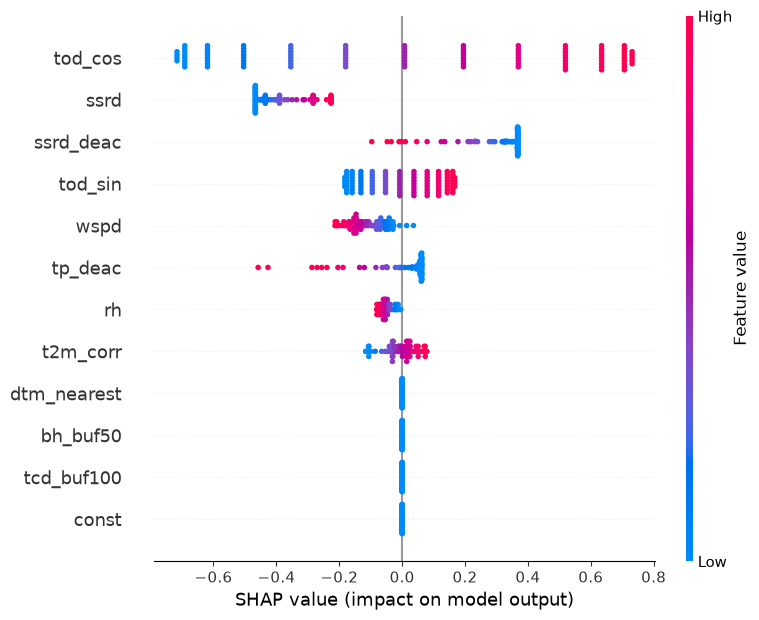

  Repetition 2/3
-- START TIME: 2025-08-20 00:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9312
added ['t2m_corr']                   recon_val_R²=0.9322
added ['u10', 'v10']                 recon_val_R²=0.9329
added ['tcd_buf100']                 recon_val_R²=0.9329
added ['imp_buf500']                 recon_val_R²=0.9329
added ssrd_deac            recon_val_R²=0.9380
added tp_deac              recon_val_R²=0.9395
added ssrd                 recon_val_R²=0.9398
LUR: 10 predictors, recon_val_R²=0.9398
ssrd_deac    -1.690177e+00
tp_deac      -1.676495e+00
const         1.084068e+00
ssrd          2.205413e-01
v10           1.980161e-01
tod_cos       1.810216e-01
u10          -1.463829e-01
t2m_corr     -1.030079e-01
tod_sin      -4.041006e-02
tcd_buf100    1.952727e-16
imp_buf500   -3.512109e-17
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 129.54it/s]


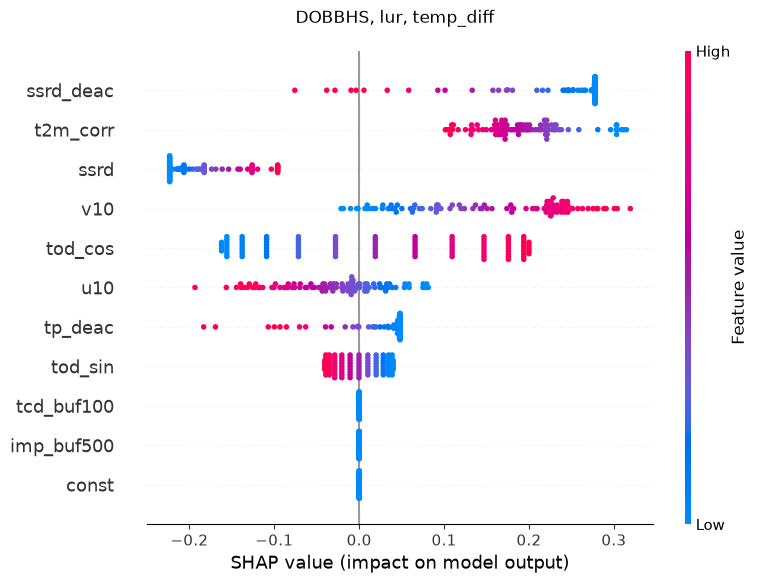

  Repetition 3/3
-- START TIME: 2025-07-06 04:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9197
added ['bh_buf250']                  recon_val_R²=0.9197
added ssrd_deac            recon_val_R²=0.9273
added tp_deac              recon_val_R²=0.9294
added ssrd                 recon_val_R²=0.9310
added tp                   recon_val_R²=0.9329
added dtm_nearest          recon_val_R²=0.9329
LUR: 8 predictors, recon_val_R²=0.9329
ssrd_deac     -1.281849e+00
const          1.074047e+00
tod_cos        5.172529e-01
ssrd           2.940066e-01
tp_deac       -1.922216e-01
tp            -1.504170e-01
tod_sin       -1.406497e-01
bh_buf250      1.889326e-16
dtm_nearest    0.000000e+00
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 500.58it/s]


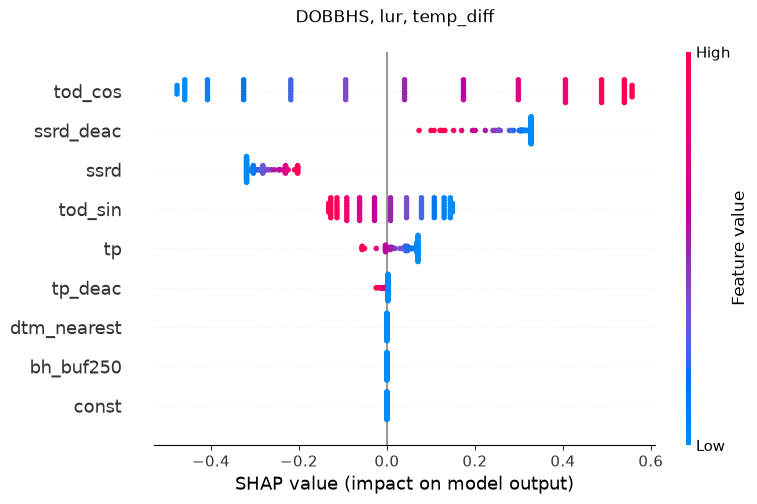

<Figure size 640x480 with 0 Axes>

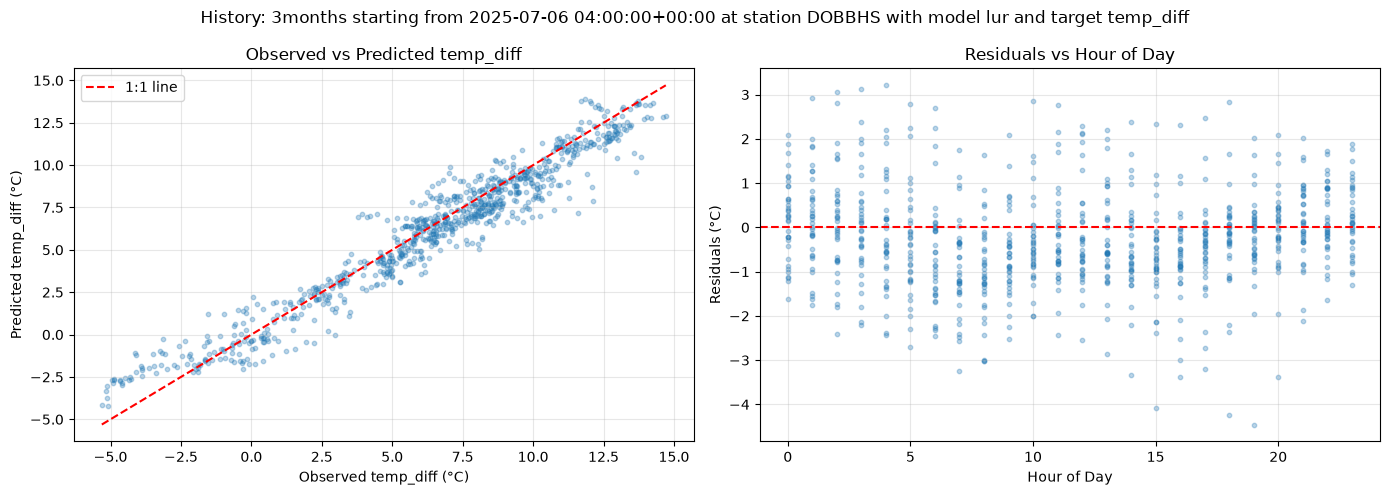


Processing 6months (4320 hours)...
  Repetition 1/3
-- START TIME: 2025-01-15 21:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9070
added ['doy_sin', 'doy_cos']         recon_val_R²=0.9071
added ['u10', 'v10']                 recon_val_R²=0.9104
added ssrd_deac            recon_val_R²=0.9165
added ssrd                 recon_val_R²=0.9275
added tp_deac              recon_val_R²=0.9295
added tp                   recon_val_R²=0.9299
added dtm_nearest          recon_val_R²=0.9299
LUR: 11 predictors, recon_val_R²=0.9299
ssrd_deac     -1.309872
const          1.291502
tp_deac       -1.146958
tod_cos        0.777820
doy_sin        0.538657
ssrd           0.448563
tp            -0.218359
v10            0.185813
doy_cos        0.160046
u10           -0.144713
tod_sin       -0.115055
dtm_nearest    0.000000
dtype: float64


100%|██████████| 100/100 [00:01<00:00, 61.67it/s]


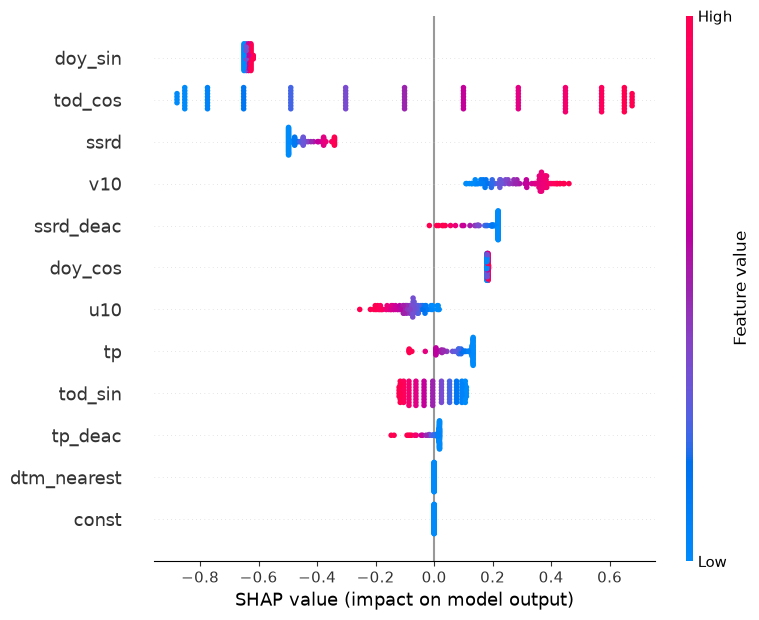

  Repetition 2/3
-- START TIME: 2025-04-11 19:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9181
added tp_deac              recon_val_R²=0.9193
added ssrd_deac            recon_val_R²=0.9208
added ssrd                 recon_val_R²=0.9262
added tp                   recon_val_R²=0.9291
LUR: 6 predictors, recon_val_R²=0.9291
const        1.142852
ssrd_deac   -0.993600
tod_cos      0.658437
ssrd         0.415517
tp_deac     -0.250562
tp          -0.198757
tod_sin     -0.129141
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 231.04it/s]


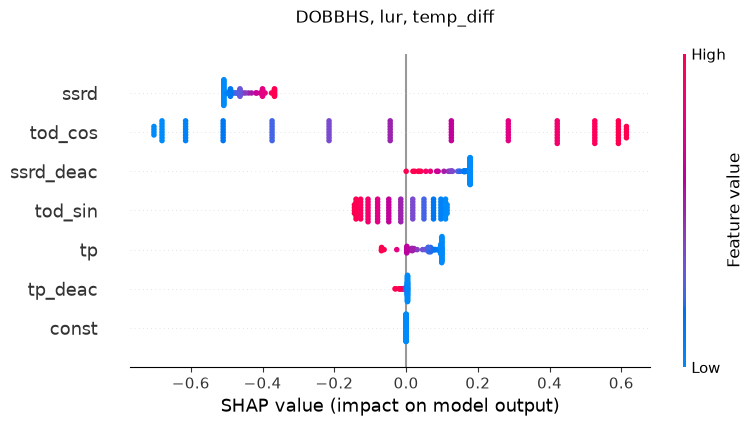

  Repetition 3/3
-- START TIME: 2025-03-14 01:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9119
added ['wspd']                       recon_val_R²=0.9120
added ['bh_buf50']                   recon_val_R²=0.9120
added ssrd_deac            recon_val_R²=0.9154
added ssrd                 recon_val_R²=0.9242
added tp_deac              recon_val_R²=0.9274
LUR: 7 predictors, recon_val_R²=0.9274
tp_deac     -1.482781e+00
const        1.377310e+00
ssrd_deac   -1.032368e+00
tod_cos      6.599110e-01
ssrd         3.522506e-01
wspd        -2.265245e-01
tod_sin     -1.994790e-01
bh_buf50    -4.834758e-16
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 209.39it/s]


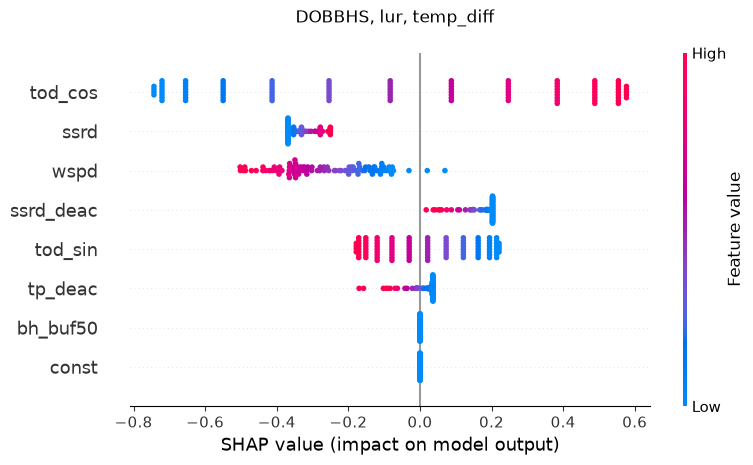

<Figure size 640x480 with 0 Axes>

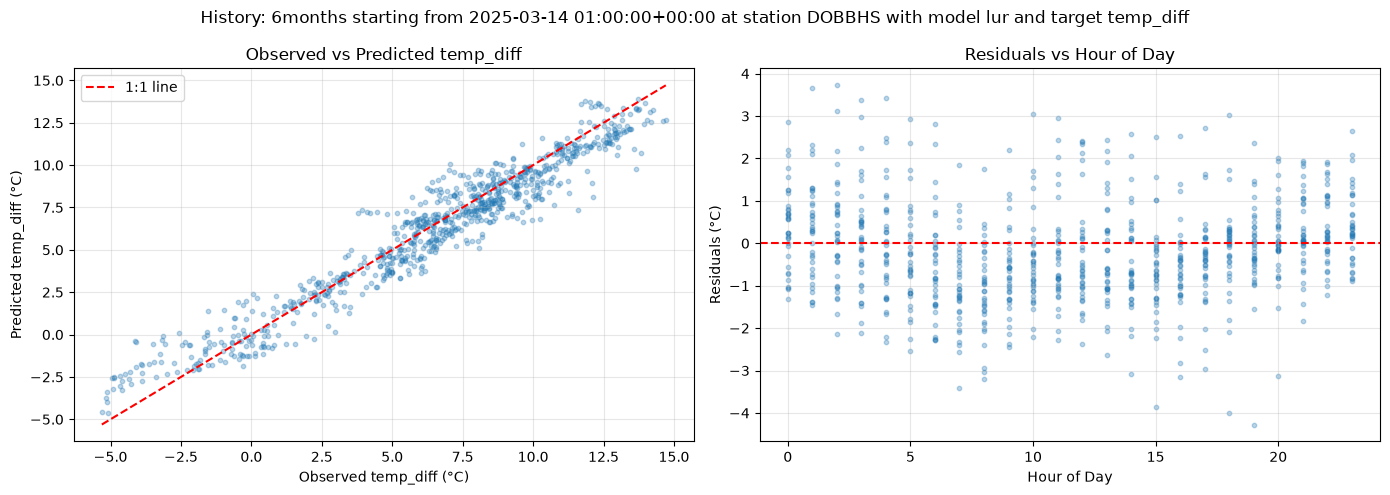


Processing 11months (7920 hours)...
  Repetition 1/3
-- START TIME: 2025-01-01 01:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9218
added ['wspd']                       recon_val_R²=0.9224
added ssrd_deac            recon_val_R²=0.9276
added ssrd                 recon_val_R²=0.9361
added tp_deac              recon_val_R²=0.9368
added dtm_nearest          recon_val_R²=0.9368
LUR: 7 predictors, recon_val_R²=0.9368
tp_deac       -2.318534
ssrd_deac     -1.999294
const          1.537674
tod_cos        0.434171
ssrd           0.378885
wspd          -0.129585
tod_sin       -0.032354
dtm_nearest    0.000000
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 223.52it/s]


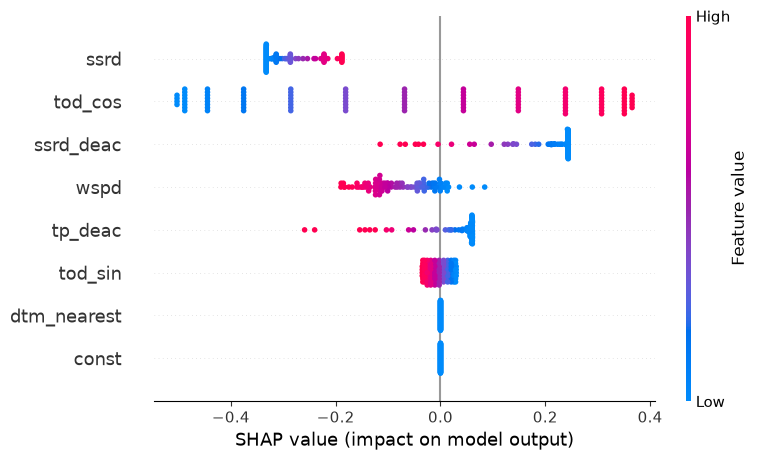

  Repetition 2/3
-- START TIME: 2025-01-01 01:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9218
added ['wspd']                       recon_val_R²=0.9224
added ssrd_deac            recon_val_R²=0.9276
added ssrd                 recon_val_R²=0.9361
added tp_deac              recon_val_R²=0.9368
added dtm_nearest          recon_val_R²=0.9368
LUR: 7 predictors, recon_val_R²=0.9368
tp_deac       -2.318534
ssrd_deac     -1.999294
const          1.537674
tod_cos        0.434171
ssrd           0.378885
wspd          -0.129585
tod_sin       -0.032354
dtm_nearest    0.000000
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 202.93it/s]


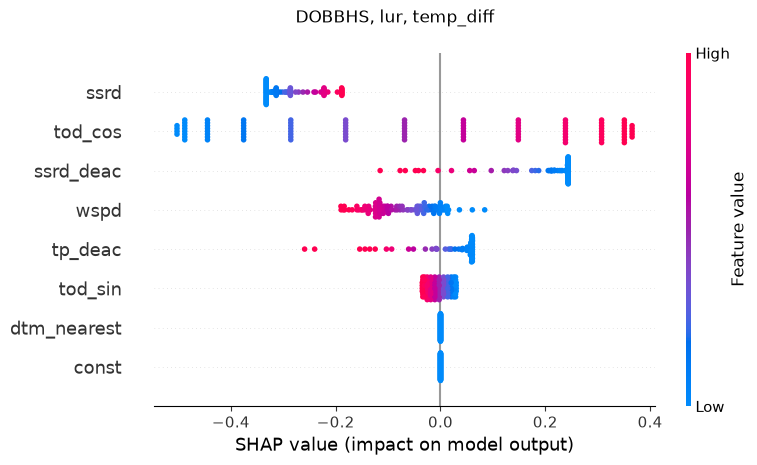

  Repetition 3/3
-- START TIME: 2025-01-01 01:00:00+00:00
added ['tod_sin', 'tod_cos']         recon_val_R²=0.9218
added ['wspd']                       recon_val_R²=0.9224
added ssrd_deac            recon_val_R²=0.9276
added ssrd                 recon_val_R²=0.9361
added tp_deac              recon_val_R²=0.9368
added dtm_nearest          recon_val_R²=0.9368
LUR: 7 predictors, recon_val_R²=0.9368
tp_deac       -2.318534
ssrd_deac     -1.999294
const          1.537674
tod_cos        0.434171
ssrd           0.378885
wspd          -0.129585
tod_sin       -0.032354
dtm_nearest    0.000000
dtype: float64


100%|██████████| 100/100 [00:00<00:00, 219.93it/s]


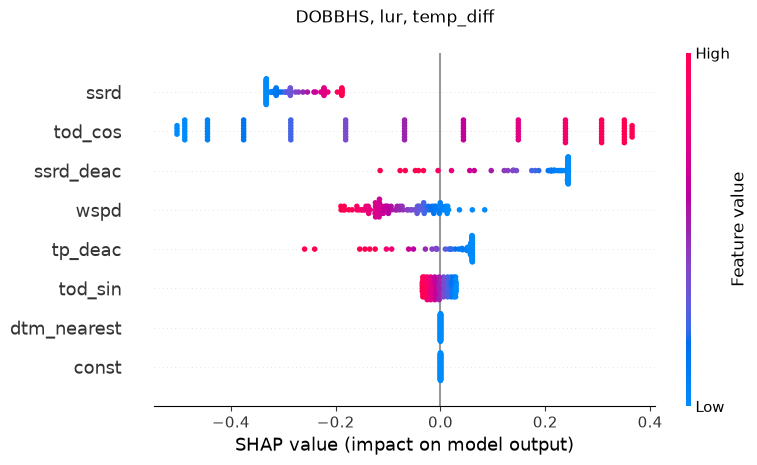

<Figure size 640x480 with 0 Axes>

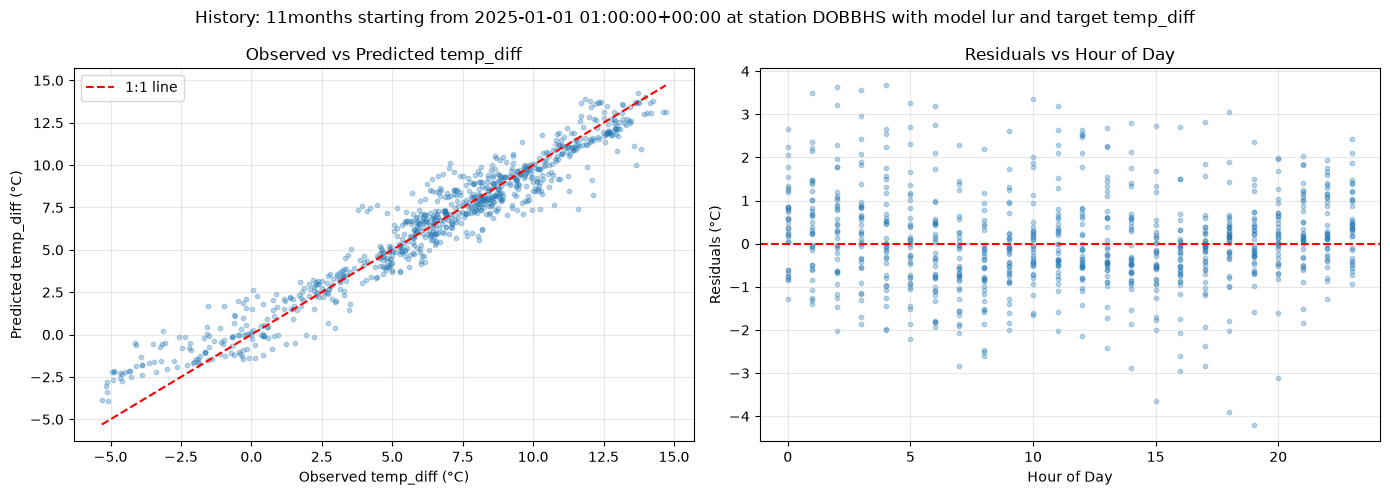

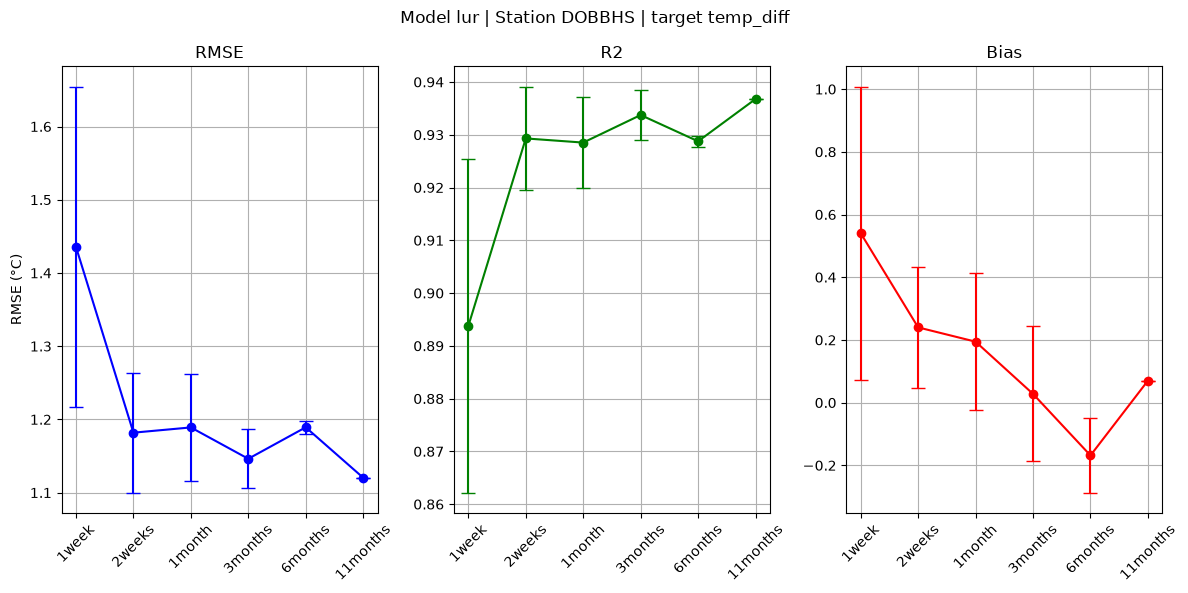


Summary of Results:

Trained with Features ['tod_sin', 'tod_cos', 'wspd', 'ssrd_deac', 'ssrd', 'tp_deac', 'dtm_nearest']
History      RMSE Mean  RMSE Std   R2 Mean    R2 Std     Bias Mean 
1week        1.44       0.22       0.89       0.03       0.54      
2weeks       1.18       0.08       0.93       0.01       0.24      
1month       1.19       0.07       0.93       0.01       0.19      
3months      1.15       0.04       0.93       0.00       0.03      
6months      1.19       0.01       0.93       0.00       -0.17     
11months     1.12       0.00       0.94       0.00       0.07      


In [19]:
results = train_and_explain_model(df, model_name="lur", target="temp_diff", city="dortmund")

In [20]:
dfs =  []
for hl in results:  # loop over history_length sorted entries
    for entry in results[hl]["cyclic_effects"]:
        impact_tod = entry["impact_tod"]

        df = pd.DataFrame({"tod":impact_tod.keys(), "impact":impact_tod.values()})
        df["history_length"] = hl
        dfs.append(df)

df = pd.concat(dfs).reset_index().drop(columns=["index"])
# df.groupby(["history_len", "tod"]).mean()
df

,tod,impact,history_length
0,0,1.111853,1week
1,1,0.891907,1week
2,2,0.611179,1week
3,3,0.288800,1week
4,4,-0.053260,1week
...,...,...,...
427,19,0.143623,11months
428,20,0.245105,11months
429,21,0.329883,11months
430,22,0.392181,11months


1week


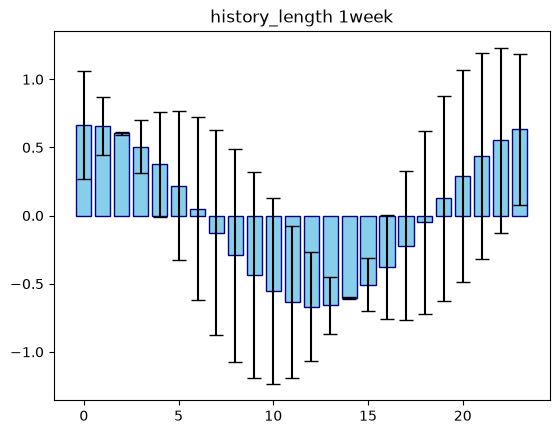

2weeks


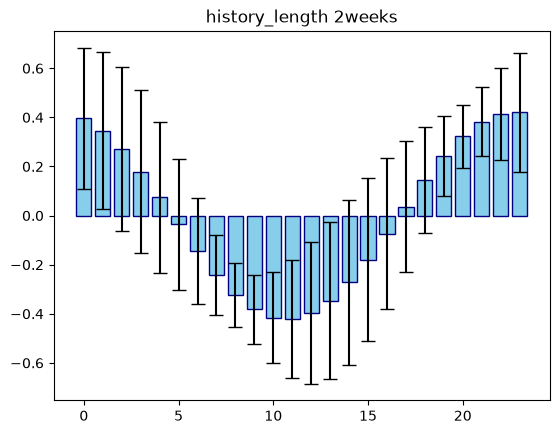

1month


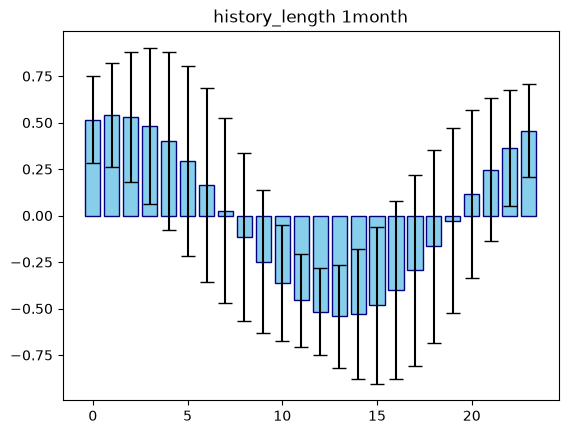

3months


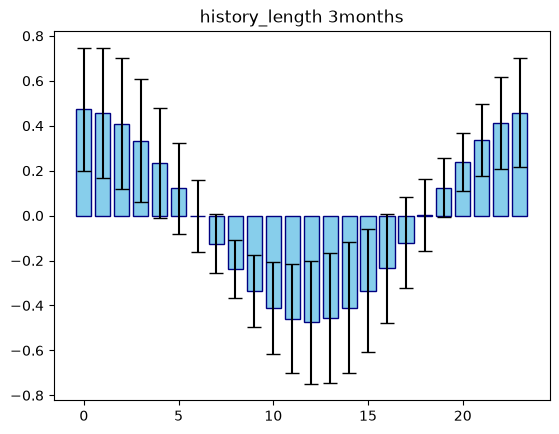

6months


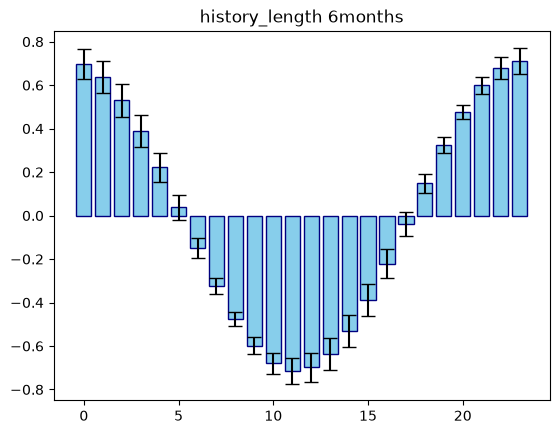

11months


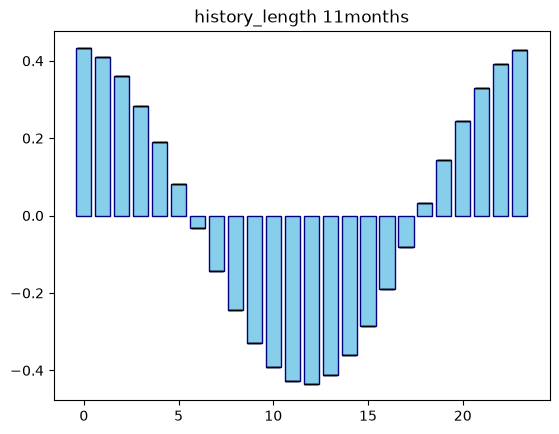

In [21]:
for hl in df["history_length"].unique():
        print(hl)
        tod_stats = df[df["history_length"]== hl].groupby('tod')['impact'].agg(['mean', 'std']).reset_index()
        

        # Create bar plot with error bars
        plt.bar(tod_stats['tod'],
                tod_stats['mean'],
                yerr=tod_stats['std'],
                capsize=5,
                color='skyblue',
                edgecolor='navy',
                )
        plt.title(f"history_length {hl}")
        plt.show()